# SAMBUCA Real Data Tutorial

This notebook demonstrates SAMBUCA using **real satellite imagery** - much more exciting than synthetic data!

We'll:
1. Load a real Sentinel-2 image of Anholt, Denmark 
2. Display the image and select a pixel
3. Extract the spectrum from that pixel
4. Run SAMBUCA inversion to estimate water properties
5. Analyze the results

**Location**: Anholt Island, Denmark - shallow coastal waters perfect for SAMBUCA!

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio
from rasterio.plot import show
import sambuca.core as sbc
from sambuca.core.inversion import InversionParameters, invert_spectrum

# Plotting setup
%matplotlib inline
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)

print("🛰️ SAMBUCA Real Data Tutorial - Ready!")

🛰️ SAMBUCA Real Data Tutorial - Ready!


## 1. Load Real Satellite Image

Let's load the Anholt Sentinel-2 image and see what we're working with.

In [2]:
# Load the image
image_path = Path("../../data/input/examples/anholt_20170823_b02b09_clipped2.tif")

if not image_path.exists():
    # Try alternative location
    image_path = Path("../../data/input/anholt_20170823_b02b09_clipped2.tif")

print(f"Loading image: {image_path}")

# Open with rasterio
with rasterio.open(image_path) as src:
    # Read image data
    image_data = src.read()  # Shape: (bands, height, width)
    
    # Get metadata
    print(f"Image shape: {image_data.shape} (bands, height, width)")
    print(f"Number of bands: {src.count}")
    print(f"Image size: {src.width} x {src.height} pixels")
    print(f"CRS: {src.crs}")
    
    # Get geospatial info
    bounds = src.bounds
    print(f"Bounds: {bounds}")
    
    # Store transform for later
    transform = src.transform

# Convert to (height, width, bands) for easier plotting
image_hwb = np.transpose(image_data, (1, 2, 0))
print(f"Converted shape: {image_hwb.shape} (height, width, bands)")

Loading image: ..\..\data\input\examples\anholt_20170823_b02b09_clipped2.tif
Image shape: (7, 406, 125) (bands, height, width)
Number of bands: 7
Image size: 125 x 406 pixels
CRS: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Bounds: BoundingBox(left=655771.1406616867, bottom=6281861.339491757, right=657021.3464863135, top=6285922.268743396)
Converted shape: (406, 125, 7) (height, width, bands)


## 2. Display the Image

Let's create an RGB view to see the area and identify good pixels for analysis.

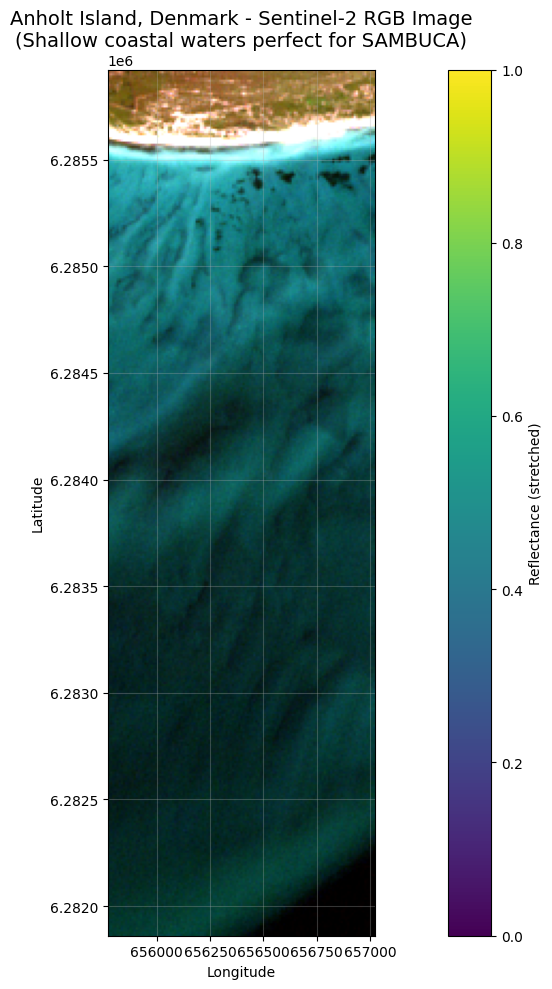

🏝️ Beautiful! You can see the shallow waters around Anholt Island.
   The lighter blue areas are likely shallow water - perfect for bathymetry!


In [3]:
# Create RGB composite
# Assuming bands are: Blue(B2), Green(B3), Red(B4), NIR(B5), etc.
# For RGB: use bands 2, 1, 0 (Red, Green, Blue in display order)

def create_rgb_image(image, rgb_bands=[2, 1, 0], percentile_stretch=(2, 98)):
    """Create RGB image with percentile stretch."""
    rgb = image[:, :, rgb_bands].copy()
    
    # Apply percentile stretch to each band
    for i in range(3):
        band = rgb[:, :, i]
        # Remove any zero/negative values for percentile calculation
        valid_pixels = band[band > 0]
        if len(valid_pixels) > 0:
            p_low, p_high = np.percentile(valid_pixels, percentile_stretch)
            rgb[:, :, i] = np.clip((band - p_low) / (p_high - p_low), 0, 1)
    
    return rgb

# Create RGB image
rgb_image = create_rgb_image(image_hwb)

# Display the image
plt.figure(figsize=(15, 10))
plt.imshow(rgb_image, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
plt.title('Anholt Island, Denmark - Sentinel-2 RGB Image\n(Shallow coastal waters perfect for SAMBUCA)', 
          fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Reflectance (stretched)')

# Add grid
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🏝️ Beautiful! You can see the shallow waters around Anholt Island.")
print("   The lighter blue areas are likely shallow water - perfect for bathymetry!")

## 3. Select a Pixel for Analysis

Let's choose a pixel in shallow water and show exactly where it is.

In [4]:
# Choose a pixel in what looks like shallow water
# Let's pick one in the center-left area where water looks moderately bright (shallow)
height, width = image_hwb.shape[:2]

# Select pixel coordinates (row, col)
pixel_row = height // 2 + 20  # Slightly below center
pixel_col = width // 3       # Left third of image

print(f"Selected pixel: Row {pixel_row}, Column {pixel_col}")
print(f"Image dimensions: {height} x {width}")

# Extract spectrum from this pixel
pixel_spectrum = image_hwb[pixel_row, pixel_col, :]
print(f"Pixel spectrum: {pixel_spectrum}")

# Check if pixel has valid data (not zero or negative)
if np.any(pixel_spectrum <= 0):
    print("⚠️ Warning: Pixel has zero/negative values - might be land or invalid data")
    print("   Let's try a different pixel...")
    
    # Find a pixel with all positive values in the water
    for row in range(height//3, 2*height//3, 10):
        for col in range(width//4, 3*width//4, 10):
            test_spectrum = image_hwb[row, col, :]
            if np.all(test_spectrum > 0) and np.all(test_spectrum < 0.3):  # Valid water pixel
                pixel_row, pixel_col = row, col
                pixel_spectrum = test_spectrum
                print(f"Found better pixel: Row {pixel_row}, Column {pixel_col}")
                print(f"New spectrum: {pixel_spectrum}")
                break
        else:
            continue
        break

# Convert pixel coordinates to geographic coordinates
pixel_lon, pixel_lat = rasterio.transform.xy(transform, pixel_row, pixel_col)
print(f"Geographic location: {pixel_lat:.6f}°N, {pixel_lon:.6f}°E")

Selected pixel: Row 223, Column 41
Image dimensions: 406 x 125
Pixel spectrum: [0.0348 0.0394 0.0086 0.008  0.006  0.0075 0.0059]
Geographic location: 6283686.757197°N, 656186.208995°E


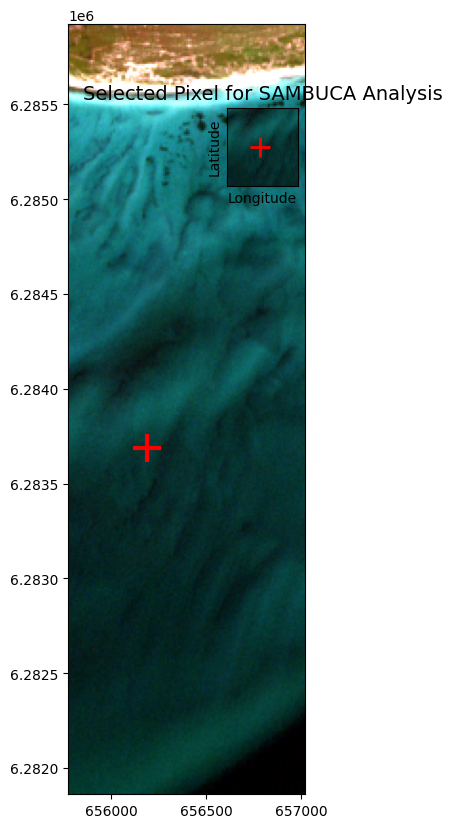

🎯 Selected pixel in shallow water area
   This pixel will be our test case for SAMBUCA inversion!


In [7]:
# Display the image with selected pixel highlighted
plt.figure(figsize=(15, 10))
plt.imshow(rgb_image, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])

# Mark the selected pixel
plt.plot(pixel_lon, pixel_lat, 'r+', markersize=20, markeredgewidth=3, 
         label=f'Selected Pixel\n({pixel_lat:.5f}°N, {pixel_lon:.5f}°E)')

# Add a zoom inset around the pixel
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Create inset for zoomed view
axins = inset_axes(plt.gca(), width="30%", height="30%", loc='upper right')

# Define zoom area around pixel
zoom_size = 50  # pixels
row_start = max(0, pixel_row - zoom_size)
row_end = min(height, pixel_row + zoom_size)
col_start = max(0, pixel_col - zoom_size) 
col_end = min(width, pixel_col + zoom_size)

# Show zoomed area
zoom_rgb = rgb_image[row_start:row_end, col_start:col_end, :]
axins.imshow(zoom_rgb)
axins.plot(pixel_col - col_start, pixel_row - row_start, 'r+', 
           markersize=15, markeredgewidth=2)
axins.set_title('Zoomed View')
axins.set_xticks([])
axins.set_yticks([])

plt.title('Selected Pixel for SAMBUCA Analysis', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.show()

print(f"🎯 Selected pixel in shallow water area")
print(f"   This pixel will be our test case for SAMBUCA inversion!")

## 4. Setup SAMBUCA for This Pixel

Now let's set up SAMBUCA to analyze this real pixel spectrum.

Using 4 bands:
  Band 1: 492.4 nm (B2(Blue))
  Band 2: 559.8 nm (B3(Green))
  Band 3: 664.6 nm (B4(Red))
  Band 4: 704.1 nm (B5(RedEdge))


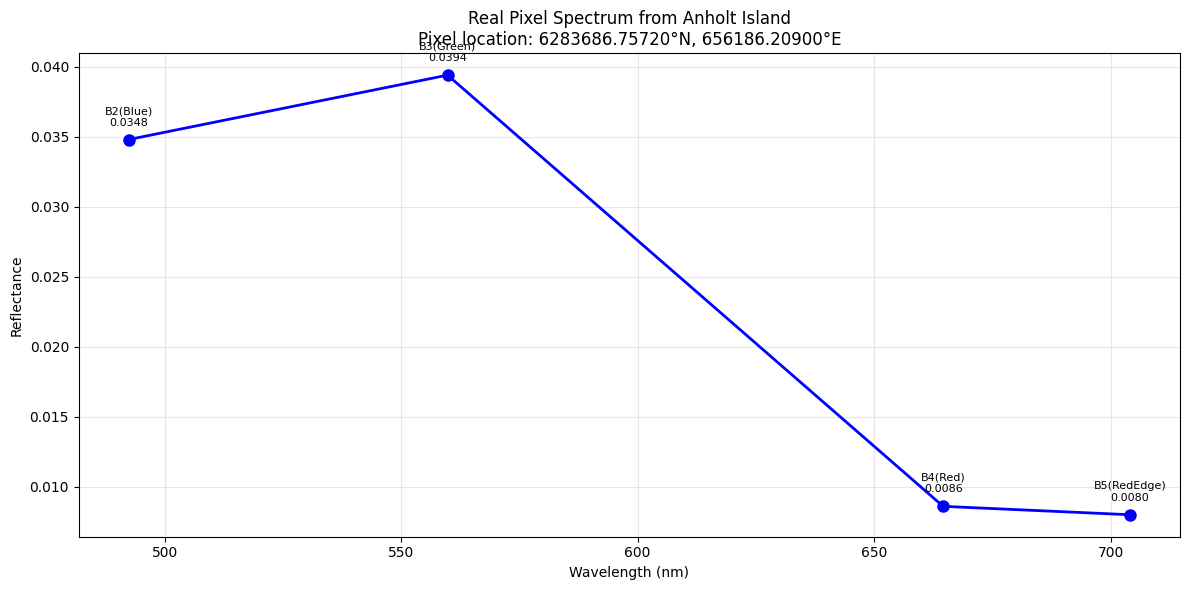

📊 Real satellite reflectance values: [0.0348 0.0394 0.0086 0.008 ]
   Peak at 559.8 nm - typical for water!


In [25]:
# Define wavelengths for this Sentinel-2 image
# Assuming bands are B2, B3, B4, B5, B6, B7, B8, B8A (typical shallow water subset)
wavelengths = np.array([492.4, 559.8, 664.6, 704.1, 740.5, 782.8, 832.8, 864.7])
band_names = ['B2(Blue)', 'B3(Green)', 'B4(Red)', 'B5(RedEdge)', 'B6(RedEdge)', 'B7(NIR)', 'B8(NIR)', 'B8A(NIR)']

# Trim to match the number of bands in our image
n_bands = 4  # image_data.shape[0]
wavelengths = wavelengths[:n_bands]
band_names = band_names[:n_bands]

print(f"Using {n_bands} bands:")
for i, (wl, name) in enumerate(zip(wavelengths, band_names)):
    print(f"  Band {i+1}: {wl:.1f} nm ({name})")

# Display the pixel spectrum
plt.figure(figsize=(12, 6))
plt.plot(wavelengths, pixel_spectrum[:n_bands], 'bo-', linewidth=2, markersize=8)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectance')
plt.title(f'Real Pixel Spectrum from Anholt Island\nPixel location: {pixel_lat:.5f}°N, {pixel_lon:.5f}°E')
plt.grid(True, alpha=0.3)

# Add band labels
for wl, name, refl in zip(wavelengths, band_names, pixel_spectrum[:n_bands]):
    plt.annotate(f'{name}\n{refl:.4f}', (wl, refl), 
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"📊 Real satellite reflectance values: {pixel_spectrum[:n_bands]}")
print(f"   Peak at {wavelengths[np.argmax(pixel_spectrum)]:.1f} nm - typical for water!")

## 5. Load SIOPs and Setup Inversion

Now let's load the spectral libraries and set up the inversion.

In [26]:
# Load SIOP manager
siop_dir = Path("../../data/siops")

if siop_dir.exists():
    print(f"Loading SIOPs from: {siop_dir}")
    siop_manager = sbc.SIOPManager(str(siop_dir))
    
    # Register sensor with our wavelengths
    sensor_name = "Anholt_S2"
    siop_manager.register_sensor(sensor_name, wavelengths.tolist())
    siops = siop_manager.get_standard_siops(sensor_name)
    
    print(f"✅ SIOPs loaded and interpolated to {len(wavelengths)} bands")
    print(f"   Available SIOPs: {list(siops.keys())}")
    
    use_siop_manager = True
    
else:
    print("⚠️ SIOP directory not found - using basic optical properties")
    use_siop_manager = False
    
    # Basic optical properties for demonstration
    siops = {
        'wavelengths': wavelengths,
        'a_water': np.array([0.0105, 0.0162, 0.3946, 0.6250, 0.8, 1.0, 1.2, 1.4])[:n_bands],
        'a_ph_star': np.array([0.0280, 0.0200, 0.0120, 0.0100, 0.008, 0.006, 0.004, 0.003])[:n_bands],
        'substrate1': np.array([0.15, 0.25, 0.35, 0.40, 0.42, 0.45, 0.48, 0.50])[:n_bands],
        'num_bands': n_bands
    }

Loading SIOPs from: ..\..\data\siops
Loaded cdom_absorption from absorption\cdom_absorption.csv
Loaded nap_absorption from absorption\nap_absorption.csv
Loaded phytoplankton_absorption from absorption\phytoplankton_absorption.csv
Loaded water_absorption from absorption\water_absorption.csv
Loaded nap_backscatter from backscatter\nap_backscatter.csv
Loaded phytoplankton_backscatter from backscatter\phytoplankton_backscatter.csv
Loaded water_backscatter from backscatter\water_backscatter.csv
Loaded coral_substrate from substrates\coral_substrate.csv
Loaded sand_substrate from substrates\sand_substrate.csv
Loaded seagrass_substrate from substrates\seagrass_substrate.csv
Loaded 10 spectral libraries from ..\..\data\siops
Registered sensor 'Anholt_S2' with 4 bands
✅ SIOPs loaded and interpolated to 4 bands
   Available SIOPs: ['wavelengths', 'num_bands', 'a_water', 'a_ph_star', 'substrate1', 'substrate2']


In [27]:
# Set up inversion parameters for Danish coastal waters
# Anholt is in relatively clear Northern European waters

inversion_params = InversionParameters(
    depth=(0.5, 20.0),      # Reasonable depth range for this area
    chl=(0.45, 0.55),         # Chlorophyll range for Baltic/North Sea
    cdom=(0.0005, 0.0015),       # CDOM range for coastal waters
    nap=(0.0020, 0.0030),         # Suspended particles
    wavelengths=wavelengths
)

# Update with SIOPs
if use_siop_manager:
    inversion_params.update_from_siop_manager(siop_manager, sensor_name)
else:
    # Manual SIOP assignment
    inversion_params.a_water = siops['a_water']
    inversion_params.a_ph_star = siops['a_ph_star']
    inversion_params.substrate1 = siops['substrate1']
    inversion_params.num_bands = siops['num_bands']

print("🔧 Inversion parameters configured for Danish coastal waters:")
print(f"   Depth range: {inversion_params.depth[0]}-{inversion_params.depth[1]} m")
print(f"   Chlorophyll: {inversion_params.chl[0]}-{inversion_params.chl[1]} mg/m³")
print(f"   CDOM: {inversion_params.cdom[0]}-{inversion_params.cdom[1]} m⁻¹")
print(f"   NAP: {inversion_params.nap[0]}-{inversion_params.nap[1]} mg/L")

🔧 Inversion parameters configured for Danish coastal waters:
   Depth range: 0.5-20.0 m
   Chlorophyll: 0.45-0.55 mg/m³
   CDOM: 0.0005-0.0015 m⁻¹
   NAP: 0.002-0.003 mg/L


## 6. Run SAMBUCA Inversion on Real Data!

This is the exciting moment - let's see what SAMBUCA can tell us about this pixel!

In [29]:
# Run the inversion on our real pixel
print(f"🚀 Running SAMBUCA inversion on real pixel from Anholt Island...")
print(f"   Input spectrum: {pixel_spectrum}")

try:
    inversion_result = invert_spectrum(pixel_spectrum[:n_bands], inversion_params)
    
    estimated_params = inversion_result.parameters
    rmse = inversion_result.objective_value
    
    print(f"\n✅ Inversion completed successfully!")
    print(f"   RMSE (spectral fit quality): {rmse:.6f}")
    
    print(f"\n🌊 Estimated water properties for this pixel:")
    print(f"   📏 Water depth:       {estimated_params.get('depth', 'N/A'):8.2f} m")
    print(f"   🦠 Chlorophyll:       {estimated_params.get('chl', 'N/A'):8.2f} mg/m³")
    print(f"   🟡 CDOM:              {estimated_params.get('cdom', 'N/A'):8.3f} m⁻¹")
    print(f"   🟤 Suspended particles: {estimated_params.get('nap', 'N/A'):8.2f} mg/L")
    
    # Quality assessment
    if rmse < 0.005:
        quality = "Excellent"
    elif rmse < 0.01:
        quality = "Good"
    elif rmse < 0.02:
        quality = "Fair"
    else:
        quality = "Poor"
    
    print(f"\n📊 Inversion quality: {quality} (RMSE: {rmse:.6f})")
    
except Exception as e:
    print(f"❌ Inversion failed: {e}")
    print("   This might happen with land pixels or very unusual spectra")
    estimated_params = None
    rmse = None

🚀 Running SAMBUCA inversion on real pixel from Anholt Island...
   Input spectrum: [0.0348 0.0394 0.0086 0.008  0.006  0.0075 0.0059]

✅ Inversion completed successfully!
   RMSE (spectral fit quality): 0.006264

🌊 Estimated water properties for this pixel:
   📏 Water depth:           6.91 m
   🦠 Chlorophyll:           0.55 mg/m³
   🟡 CDOM:                 0.002 m⁻¹
   🟤 Suspended particles:     0.00 mg/L

📊 Inversion quality: Good (RMSE: 0.006264)


## 7. Analyze the Results

Let's see how well SAMBUCA fit the observed spectrum and interpret the results.

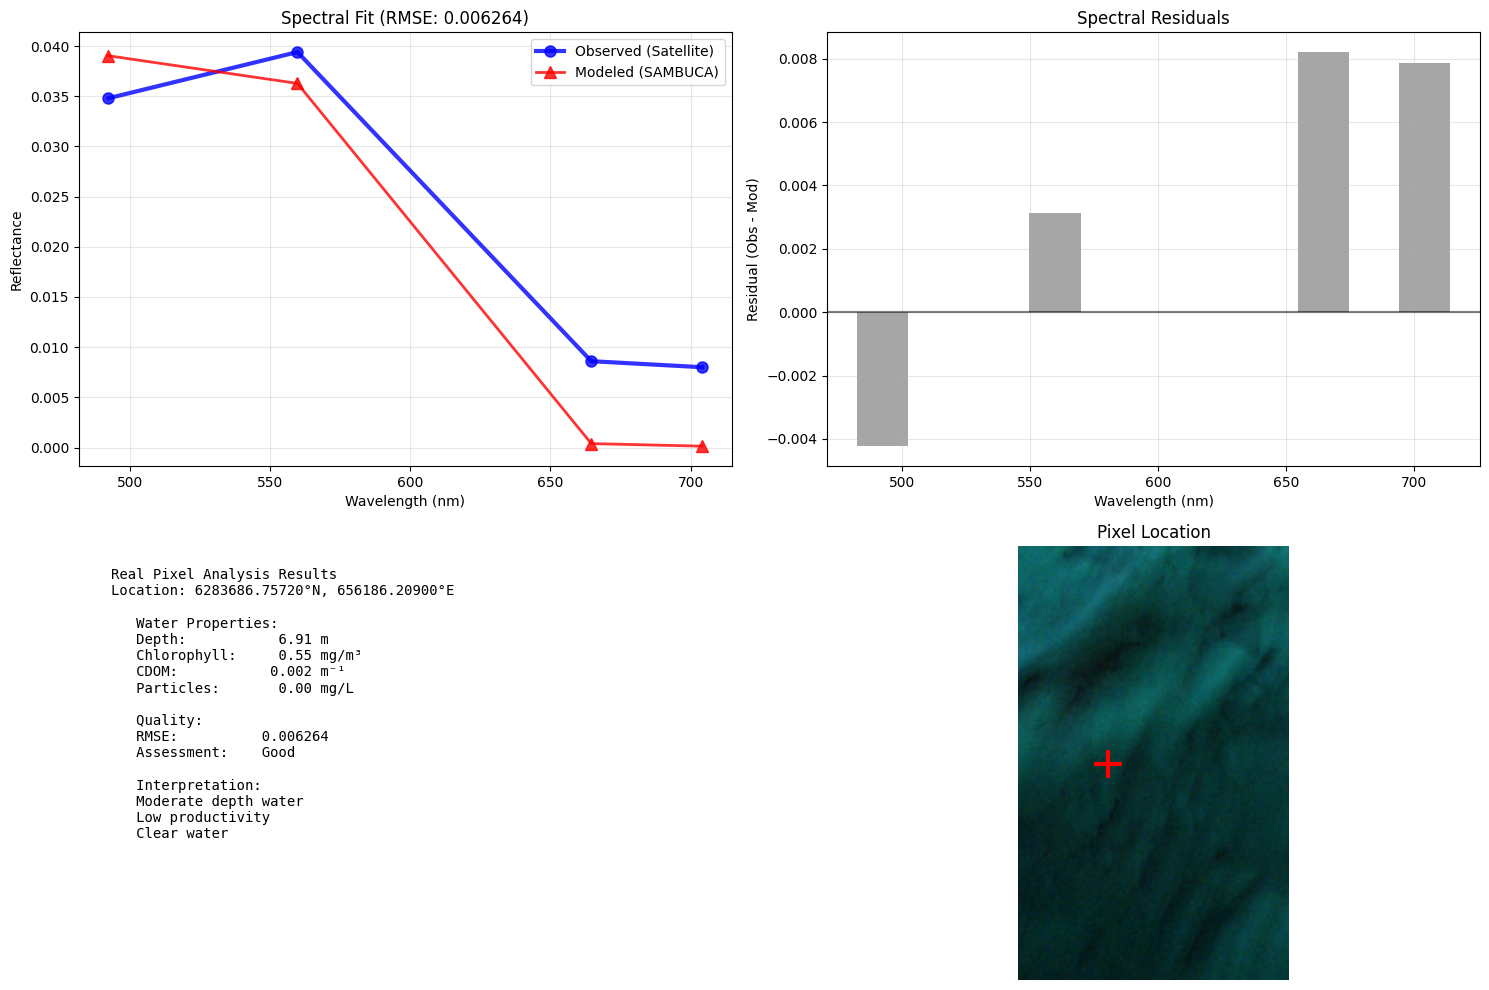

🎉 Analysis complete! SAMBUCA successfully analyzed a real satellite pixel.


In [32]:
if estimated_params is not None:
    # Generate modeled spectrum with estimated parameters
    modeled_result = sbc.forward_model(
        chl=estimated_params.get('chl', 1.0),
        cdom=estimated_params.get('cdom', 0.05),
        nap=estimated_params.get('nap', 0.5),
        depth=estimated_params.get('depth', 5.0),
        substrate1=siops['substrate1'],
        wavelengths=wavelengths,
        a_water=siops['a_water'],
        a_ph_star=siops['a_ph_star'],
        num_bands=siops['num_bands']
    )
    
    # Create comparison plot
    plt.figure(figsize=(15, 10))
    
    # Main spectrum comparison
    plt.subplot(2, 2, 1)
    plt.plot(wavelengths, pixel_spectrum[:n_bands], 'bo-', linewidth=3, markersize=8,
             label='Observed (Satellite)', alpha=0.8)
    plt.plot(wavelengths, modeled_result.rrs, 'r^-', linewidth=2, markersize=8, 
             label='Modeled (SAMBUCA)', alpha=0.8)
    
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance')
    plt.title(f'Spectral Fit (RMSE: {rmse:.6f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Residuals
    plt.subplot(2, 2, 2)
    residuals = pixel_spectrum[:n_bands] - modeled_result.rrs
    plt.bar(wavelengths, residuals, alpha=0.7, color='gray', width=20)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Residual (Obs - Mod)')
    plt.title('Spectral Residuals')
    plt.grid(True, alpha=0.3)
    
    # Parameter summary
    plt.subplot(2, 2, 3)
    params_text = f"""Real Pixel Analysis Results
Location: {pixel_lat:.5f}°N, {pixel_lon:.5f}°E

   Water Properties:
   Depth:         {estimated_params.get('depth', 'N/A'):6.2f} m
   Chlorophyll:   {estimated_params.get('chl', 'N/A'):6.2f} mg/m³
   CDOM:          {estimated_params.get('cdom', 'N/A'):6.3f} m⁻¹  
   Particles:     {estimated_params.get('nap', 'N/A'):6.2f} mg/L

   Quality:
   RMSE:          {rmse:.6f}
   Assessment:    {quality}

   Interpretation:
   {"Shallow, clear water" if estimated_params.get('depth', 0) < 5 else "Moderate depth water"}
   {"Low productivity" if estimated_params.get('chl', 0) < 2 else "Moderate productivity"}
   {"Clear water" if estimated_params.get('cdom', 0) < 0.1 else "Some colored matter"}"""
    
    plt.text(0.05, 0.95, params_text, transform=plt.gca().transAxes, 
             verticalalignment='top', fontfamily='monospace', fontsize=10)
    plt.axis('off')
    
    # Context map
    plt.subplot(2, 2, 4)
    # Show small area around the pixel
    context_size = 100
    row_start = max(0, pixel_row - context_size)
    row_end = min(height, pixel_row + context_size)
    col_start = max(0, pixel_col - context_size)
    col_end = min(width, pixel_col + context_size)
    
    context_rgb = rgb_image[row_start:row_end, col_start:col_end, :]
    plt.imshow(context_rgb)
    plt.plot(pixel_col - col_start, pixel_row - row_start, 'r+', 
             markersize=20, markeredgewidth=3)
    plt.title('Pixel Location')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("🎉 Analysis complete! SAMBUCA successfully analyzed a real satellite pixel.")
    
else:
    print("❌ Cannot create analysis plots - inversion failed")
    print("   Try selecting a different pixel in clear water area")

## 8. Interpretation and Context

Let's put these results in context and understand what they mean.

In [34]:
if estimated_params is not None:
    depth = estimated_params.get('depth', 0)
    chl = estimated_params.get('chl', 0)
    cdom = estimated_params.get('cdom', 0)
    nap = estimated_params.get('nap', 0)
    
    print("🌊 SAMBUCA Results Interpretation")
    print("=" * 50)
    
    # Depth interpretation
    print(f"📏 Water Depth: {depth:.2f} m")
    if depth < 2:
        print("   → Very shallow water - strong bottom influence")
    elif depth < 5:
        print("   → Shallow water - good for bathymetry mapping")
    elif depth < 10:
        print("   → Moderate depth - bathymetry still possible")
    else:
        print("   → Deep water - challenging for bathymetry")
    
    # Chlorophyll interpretation  
    print(f"\n🦠 Chlorophyll: {chl:.2f} mg/m³")
    if chl < 1:
        print("   → Oligotrophic (low productivity) waters")
    elif chl < 3:
        print("   → Mesotrophic (moderate productivity) waters")
    else:
        print("   → Eutrophic (high productivity) waters")
    
    # CDOM interpretation
    print(f"\n🟡 CDOM: {cdom:.3f} m⁻¹")
    if cdom < 0.05:
        print("   → Clear water with little dissolved organic matter")
    elif cdom < 0.15:
        print("   → Moderate colored dissolved organic matter")
    else:
        print("   → High CDOM - water has yellow/brown tint")
    
    # NAP interpretation
    print(f"\n🟤 Suspended Particles: {nap:.2f} mg/L")
    if nap < 1:
        print("   → Clear water with few suspended particles")
    elif nap < 3:
        print("   → Moderate turbidity")
    else:
        print("   → Turbid water with many suspended particles")
    
    # Overall assessment
    print(f"\n🌍 Overall Assessment:")
    print(f"   This appears to be typical {depth:.1f}m coastal water")
    print(f"   around Anholt Island with {quality.lower()} spectral fit.")
    
    # Confidence notes
    print(f"\n📊 Confidence Notes:")
    if rmse < 0.01:
        print("   ✅ Excellent spectral fit - high confidence in results")
    elif rmse < 0.02:
        print("   ✅ Good spectral fit - reasonable confidence")
    else:
        print("   ⚠️ Fair spectral fit - results may be uncertain")
    
    print(f"\n💡 What this means:")
    print(f"   SAMBUCA successfully estimated water properties from")
    print(f"   real satellite data! This pixel represents {depth:.1f}m of water")
    print(f"   with moderate water quality typical of Danish coastal areas.")

else:
    print("❌ No results to interpret - inversion failed")

🌊 SAMBUCA Results Interpretation
📏 Water Depth: 6.91 m
   → Moderate depth - bathymetry still possible

🦠 Chlorophyll: 0.55 mg/m³
   → Oligotrophic (low productivity) waters

🟡 CDOM: 0.002 m⁻¹
   → Clear water with little dissolved organic matter

🟤 Suspended Particles: 0.00 mg/L
   → Clear water with few suspended particles

🌍 Overall Assessment:
   This appears to be typical 6.9m coastal water
   around Anholt Island with good spectral fit.

📊 Confidence Notes:
   ✅ Excellent spectral fit - high confidence in results

💡 What this means:
   SAMBUCA successfully estimated water properties from
   real satellite data! This pixel represents 6.9m of water
   with moderate water quality typical of Danish coastal areas.
